In [40]:
import matplotlib.pyplot as plt

# Path to the log file
log_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_adni_all/2025-03-10T14-06-30-accu100_lr2e04_mixnorm_cycle_warmup3000_nodiagnoal'
# Read the log file content
with open(log_path, 'r') as f:
    log_content = f.readlines()

# Process the log to extract loss values
losses = []
for line in log_content[10000:64500]:
    if 'loss' in line:  # Only process lines containing 'loss'
        parts = line.split("'loss':")  # Split to isolate the loss value
        loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        losses.append(loss)

# Group losses by epoch (20 steps per epoch)
epoch_size = 5
average_losses = [
    sum(losses[i:i+epoch_size]) / len(losses[i:i+epoch_size])
    for i in range(0, len(losses), epoch_size)
]

# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(average_losses) + 1), average_losses, marker='o', label="Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()


IsADirectoryError: [Errno 21] Is a directory: '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_adni_all/2025-03-10T14-06-30-accu100_lr2e04_mixnorm_cycle_warmup3000_nodiagnoal'

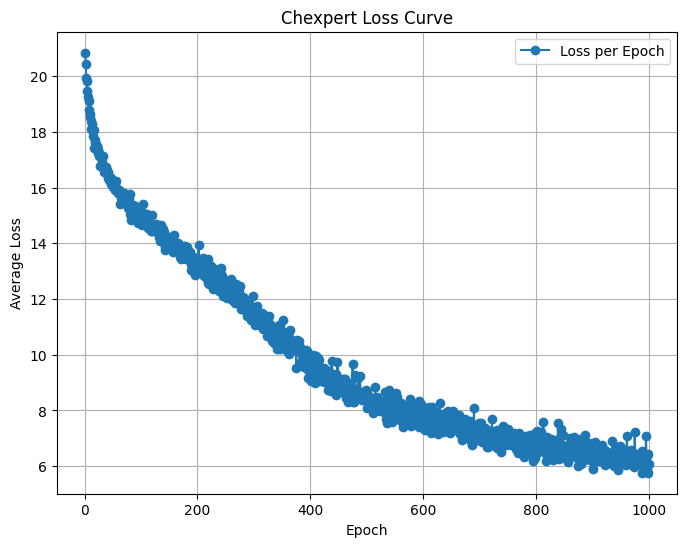

In [15]:
import matplotlib.pyplot as plt

# Path to the log file
log_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_chexpert_data100/2024-12-05T22-44-50-controlnet_intial_mcplall/logs.txt'
# Read the log file content
with open(log_path, 'r') as f:
    log_content = f.readlines()

# Process the log to extract loss values
losses = []
for line in log_content:
    if 'loss' in line:  # Only process lines containing 'loss'
        parts = line.split("'loss':")  # Split to isolate the loss value
        loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        losses.append(loss)

# Group losses by epoch (20 steps per epoch)
epoch_size = 15
average_losses = [
    sum(losses[i:i+epoch_size]) / len(losses[i:i+epoch_size])
    for i in range(0, len(losses), epoch_size)
]

# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(average_losses) + 1), average_losses, marker='o', label="Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Chexpert Loss Curve")
plt.legend()
plt.grid()
plt.show()


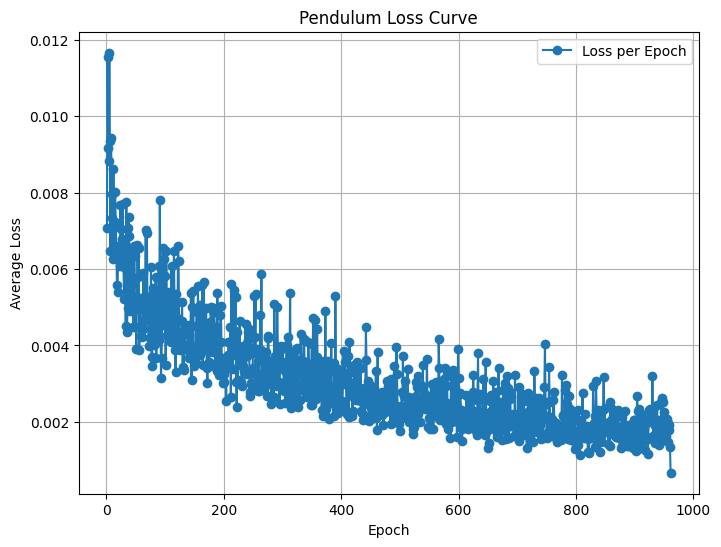

In [23]:
import matplotlib.pyplot as plt

# Path to the log file
log_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_pendulum_data100/2024-12-16T12-26-15-controlnet_intial_mcplall/logs.txt'

# Read the log file content
with open(log_path, 'r') as f:
    log_content = f.readlines()

# Process the log to extract loss values
losses = []
for line in log_content:
    if 'loss' in line:  # Only process lines containing 'loss'
        parts = line.split("'loss':")  # Split to isolate the loss value
        loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        losses.append(loss)

# Group losses by epoch (20 steps per epoch)
epoch_size = 15
average_losses = [
    sum(losses[i:i+epoch_size]) / len(losses[i:i+epoch_size])
    for i in range(0, len(losses), epoch_size)
]

# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(average_losses) + 1), average_losses, marker='o', label="Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Pendulum Loss Curve")
plt.legend()
plt.grid()
plt.show()


In [5]:
# show the learnd causal matrix
import numpy as np
threhold = 0.3
cm_name = "CM-1400.csv"
root_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_chexpert_data100/2025-02-11T15-32-08-cd_only_attributes/'
cm = np.loadtxt(root_path+cm_name,delimiter=',')
#cm[np.abs(cm) < threhold] = 0
cm

array([[3.23732966e-05, 3.25739607e-02, 2.24793497e-02],
       [1.12320820e-03, 1.78044465e-05, 1.91361271e-03],
       [2.85115000e-03, 2.40926128e-02, 4.06035178e-05]])

# Causal Discovery 

In [10]:
line.split("'causal_loss':")[1].split(",")[0].strip()

'0.0'

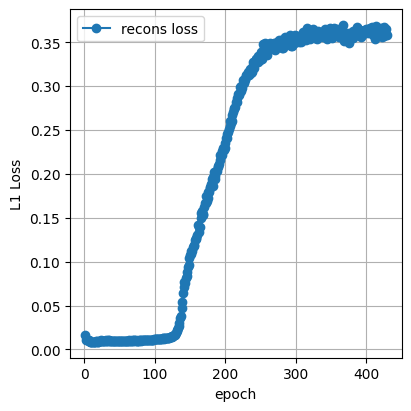

In [11]:
import matplotlib.pyplot as plt
import os
import numpy as np
# Path to the log file
log_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_pendulum_all/2025-06-20T15-06-29-textcond_noreg_nomask'
log_path = os.path.join(log_path,'logs.txt')
# Read the log file content
with open(log_path, 'r') as f:
    log_content = f.readlines()

# Process the log to extract loss values
recons_losses = []
dag_losses = []
for line in log_content[:]:
    if 'loss' in line:  # Only process lines containing 'loss'
        parts = line.split("'recons_loss':")  # Split to isolate the loss value
        rec_loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        parts = line.split("'causal_loss':")  # Split to isolate the loss value
        cau_loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        recons_losses.append(rec_loss)
        dag_losses.append(cau_loss)

# Group losses by epoch (20 steps per epoch)
epoch_size = 140
average_recon_losses = [
    sum(recons_losses[i:i+epoch_size]) / len(recons_losses[i:i+epoch_size])
    for i in range(0, len(recons_losses), epoch_size)
]

average_dag_losses = [
    sum(dag_losses[i:i+epoch_size]) / len(dag_losses[i:i+epoch_size])
    for i in range(0, len(dag_losses), epoch_size)
]
# Plot the loss curve
fig, axes = plt.subplots(1, 1, figsize=(4,4), constrained_layout=True)
axes.plot(range(1, len(average_recon_losses) + 1), average_recon_losses, marker='o', label="recons loss")
#axes.plot(range(1, len(average_dag_losses) + 1), np.sqrt(average_dag_losses), marker='o', label="dag loss")
plt.xlabel("epoch")
plt.ylabel("L1 Loss")
axes.legend()
plt.grid()
plt.show()


In [9]:
average_recon_losses[20:40]

[0.11367186412680894,
 0.11425952655263245,
 0.10940329688601196,
 0.10699725010199472,
 0.10647286529419944,
 0.10831017771270127,
 0.10802024421282112,
 0.10828240111004561,
 0.10737531884806231,
 0.10848341303644701,
 0.10858367204200477,
 0.12266113783698529,
 0.12370946798473596,
 0.12468598717823624,
 0.12390099291224033,
 0.12405609884299337,
 0.12351161122787743,
 0.12196068689227105,
 0.12476092290598899,
 0.12436502280179411]

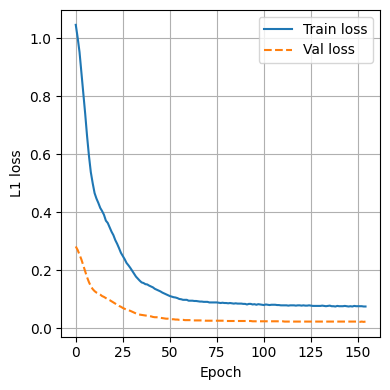

In [21]:
import re
import matplotlib.pyplot as plt

# 读取 log.txt
with open('/home/jovyan/fcvm-data-volume/kzzr229/workspace/log.txt', 'r') as f:
    lines = f.readlines()

train_l1_attrs_last2 = []
val_l1_attrs_last2 = []

# 解析每一行
for i in range(0, len(lines), 2):  # 每两行是一组：Epoch 和 Validation
    train_line = lines[i]
    val_line = lines[i + 1]

    # 从训练行中提取 l1_attrs
    train_match = re.search(r'l1_attrs=\[([0-9\.,\s]+)\]', train_line)
    val_match = re.search(r'l1_attrs=\[([0-9\.,\s]+)\]', val_line)

    if train_match and val_match:
        train_attrs = list(map(float, train_match.group(1).split(',')))
        val_attrs = list(map(float, val_match.group(1).split(',')))

        train_l1_attrs_last2.append(train_attrs[-2:])
        val_l1_attrs_last2.append(val_attrs[-2:])

# 转置为每列一组曲线
train_l1_1 = np.array([pair[0] for pair in train_l1_attrs_last2])
train_l1_2 = np.array([pair[1] for pair in train_l1_attrs_last2])
val_l1_1 = np.array([pair[0] for pair in val_l1_attrs_last2])
val_l1_2 = np.array([pair[1] for pair in val_l1_attrs_last2])

epochs = list(range(len(train_l1_1)))

# 绘图
plt.figure(figsize=(4, 4))
plt.plot(epochs, train_l1_1+train_l1_2, label='Train loss')
plt.plot(epochs, val_l1_1+val_l1_2, label='Val loss', linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('L1 loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import os
# Path to the log file
log_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_adni_all/2025-03-11T16-24-46-DAG3_lr1e05_normcontinue_warmup5000_BN'
log_path = os.path.join(log_path,'logs.txt')
# Read the log file content
with open(log_path, 'r') as f:
    log_content = f.readlines()

# Process the log to extract loss values
recons_losses = []
dag_losses = []
for line in log_content[:]:
    if 'loss' in line:  # Only process lines containing 'loss'
        parts = line.split("'recons_loss':")  # Split to isolate the loss value
        rec_loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        parts = line.split("'causal_loss':")  # Split to isolate the loss value
        cau_loss = float(parts[1].split(",")[0].strip())  # Extract and convert to float
        recons_losses.append(rec_loss)
        dag_losses.append(cau_loss)

# Group losses by epoch (20 steps per epoch)
epoch_size = 10
average_recon_losses = [
    sum(recons_losses[i:i+epoch_size]) / len(recons_losses[i:i+epoch_size])
    for i in range(0, len(recons_losses), epoch_size)
]

average_dag_losses = [
    sum(dag_losses[i:i+epoch_size]) / len(dag_losses[i:i+epoch_size])
    for i in range(0, len(dag_losses), epoch_size)
]
# Plot the loss curve
fig, axes = plt.subplots(1, 2, figsize=(8,4), constrained_layout=True)
axes[0].plot(range(1, len(average_recon_losses) + 1), average_recon_losses, marker='o', label="recon Loss per Epoch")
axes[1].plot(range(1, len(average_dag_losses) + 1), average_dag_losses, marker='o', label="dag Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
axes[0].legend()
axes[1].legend()
plt.grid()
plt.show()


In [6]:
from torchvision.datasets import CelebA

data_dir = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/"
data = CelebA(root=data_dir, split='train', transform=None, download=False)

In [15]:
selected_item = ['Smiling','Eyeglasses']
attribute_ids = [data.attr_names.index(attr) for attr in selected_item]

In [17]:
import torch
selected_item = ['Smiling','Eyeglasses']
attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

attrs = torch.cat([metrics[attr].unsqueeze(1)
                        for attr in selected_item], dim=1)
possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}

In [19]:
attrs

tensor([[1., 0.],
        [1., 0.],
        [0., 0.],
        ...,
        [1., 0.],
        [1., 0.],
        [0., 0.]])